[Font] 已检测到中文字体: WenQuanYi Micro Hei
步骤1：1D逆问题原理——扩散后验采样

1D逆问题：去噪 y = x + n, σ_obs=0.5
  真实均值: 0.0846
  观测值 y: -1.3924

无条件采样: μ=0.0509, σ²=2.9463
后验采样:   μ=-1.4327, σ²=0.1505
真实均值:   μ=0.0846
观测值:     y=-1.3924

关键：后验采样的均值更接近观测值y（似然项的约束效果）

步骤2：deepinv扩散后验采样——图像去模糊
deepinv库已安装
使用设备: cuda
  脚本目录: /public/home/acl2shcu63/实验7.5 扩散模型求解逆问题
  模型目录: /public/home/acl2shcu63/实验7.5 扩散模型求解逆问题/models
  NCSNpp: /public/home/acl2shcu63/实验7.5 扩散模型求解逆问题/models/edm-ffhq-64x64-uncond-ve.pt (存在: True)
  DRUNet: /public/home/acl2shcu63/实验7.5 扩散模型求解逆问题/models/drunet_deepinv_color_finetune_22k.pth (存在: True)
正在加载预训练模型NCSNpp（VE-SDE得分网络，FFHQ 64x64）...
  -> 从本地加载: /public/home/acl2shcu63/实验7.5 扩散模型求解逆问题/models/edm-ffhq-64x64-uncond-ve.pt
模型加载成功
加载模糊核...
  -> 从本地加载模糊核: /public/home/acl2shcu63/实验7.5 扩散模型求解逆问题/models/Levin09.npy
正在执行扩散后验采样（DPS）...
重建结果: shape=torch.Size([1, 3, 64, 64]), min=0.649, max=0.837


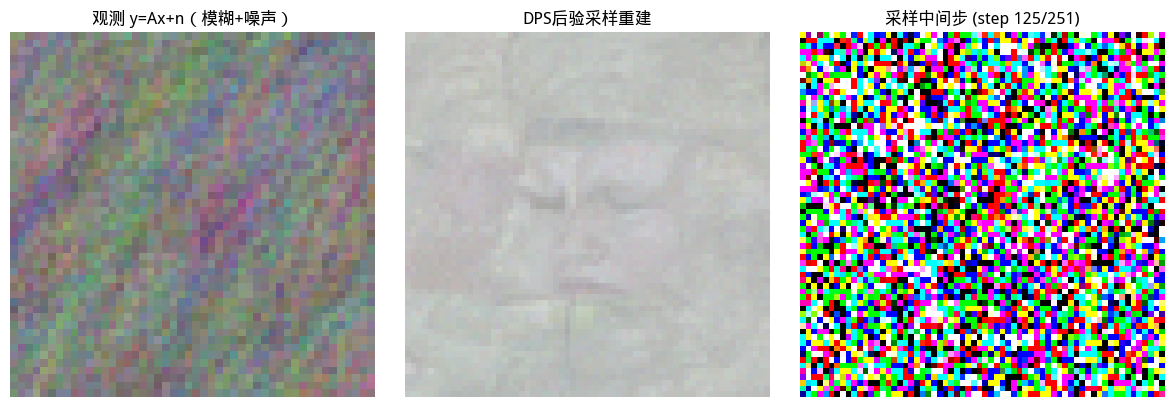

DPS重建PSNR: 8.39 dB

步骤3：DPS vs DiffPIR算法对比
正在运行DiffPIR...
  -> 从本地加载: /public/home/acl2shcu63/实验7.5 扩散模型求解逆问题/models/drunet_deepinv_color_finetune_22k.pth
DiffPIR执行出错: DiffPIR.__init__() got an unexpected keyword argument 'denoiser'
DiffPIR需要DRUNet模型，请确保GPU内存充足


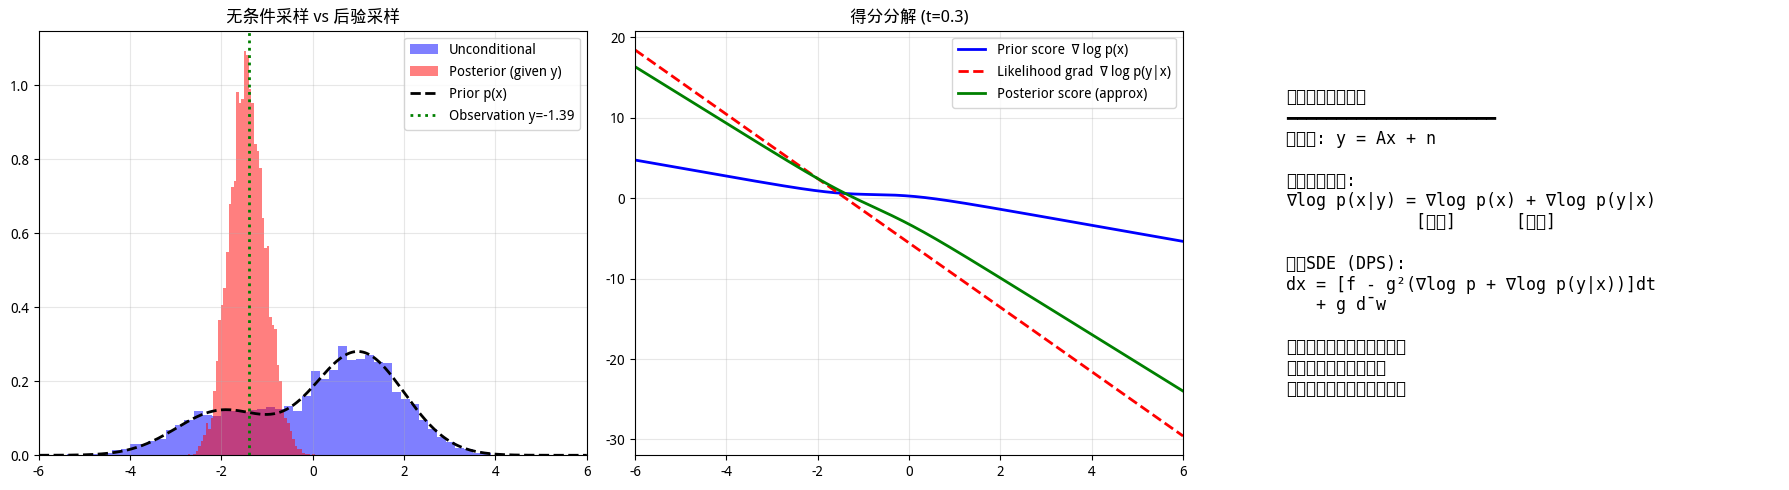


实验7.5 总结
1. 扩散后验采样的核心：后验得分 = 先验得分 + 似然梯度
   ∇log p(x|y) = ∇log p(x) + ∇log p(y|x)
2. DPS方法：在逆向SDE中用Tweedie估计x̂_0，然后计算似然梯度
3. DiffPIR方法：PnP思想融入扩散采样，交替执行去噪和数据保真投影
4. 扩散模型作为先验的优势：
   - 无需显式定义先验分布，得分函数隐含先验信息
   - 可以量化不确定性（多次采样→后验方差）
   - 适用于各种线性/非线性逆问题
5. 步骤2-3需要GPU和deepinv库，步骤1纯CPU即可理解核心原理


In [3]:
"""
实验7.5 扩散模型求解逆问题
对应章节：7.6（实践：用扩散SDE实现图像生成）
素材来源：
  - MiniProject_DenoisingPrior.ipynb的deepinv框架
  - deepinv库的demo_diffusion_sde, demo_dps, demo_diffpir
  - ★ 原创设计：1D逆问题原理演示（先理解原理再看图像）
  - ★ 原创设计：DPS vs DiffPIR vs DDRM算法对比

实验内容：
  步骤1：1D逆问题原理——扩散后验采样 vs 无条件采样
  步骤2：deepinv扩散后验采样——图像去模糊
  步骤3：DPS vs DiffPIR算法对比

运行前提：
  - 步骤1：纯NumPy/PyTorch CPU即可
  - 步骤2-3：需要GPU + deepinv库 + 预训练模型（自动下载）

安装deepinv：pip install git+https://github.com/deepinv/deepinv.git#egg=deepinv
"""

import numpy as np
import os
import sys

# ====== Windows控制台UTF-8输出 ======
if sys.platform == 'win32':
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
import matplotlib.pyplot as plt
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager
def _find_chinese_font():
    candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong'] if platform.system() == 'Windows' else ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'SimHei']
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os as _os, re
    for f in fm.ttflist:
        for pat in ['cjk', 'wqy', 'noto.*cjk', 'simhei']:
            if re.search(pat, f.name.lower()):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
# ========================================================

np.random.seed(42)
import torch
torch.manual_seed(42)

_SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
# 尝试检测models目录是否存在，不存在则向上搜索
if not os.path.isdir(os.path.join(_SCRIPT_DIR, "models")):
    # 可能是从其他目录运行的，尝试用脚本内容定位
    _candidate = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else None
    if _candidate and os.path.isdir(os.path.join(_candidate, "models")):
        _SCRIPT_DIR = _candidate


# ============================================================
# 步骤1：1D逆问题原理演示
# ★ 原创设计
# 问题：y = Ax + n，已知y和A，求x的后验p(x|y)
# 扩散后验采样：在逆向SDE中加入似然梯度
# ============================================================
print("=" * 60)
print("步骤1：1D逆问题原理——扩散后验采样")
print("=" * 60)

# 目标分布：1D高斯混合
def gm1d_pdf(x, weights=[0.3, 0.7], means=[-2, 1], stds=[1, 1]):
    pdf = np.zeros_like(x)
    for w, m, s in zip(weights, means, stds):
        pdf += w * np.exp(-0.5 * ((x - m) / s)**2) / (s * np.sqrt(2 * np.pi))
    return pdf

def vp_marginal(t, beta_min=0.1, beta_max=20.0):
    log_mean = -0.25 * t**2 * (beta_max - beta_min) - 0.5 * t * beta_min
    mean_t = np.exp(log_mean)
    std_t = np.sqrt(1 - np.exp(2 * log_mean))
    return mean_t, std_t

def vp_beta(t, beta_min=0.1, beta_max=20.0):
    return beta_min + t * (beta_max - beta_min)

def vp_score_analytic(x, t, beta_min=0.1, beta_max=20.0):
    mean_t, std_t = vp_marginal(t, beta_min, beta_max)
    pdf = np.zeros_like(x)
    dpdf = np.zeros_like(x)
    weights = [0.3, 0.7]
    means = [-2, 1]
    stds = [1, 1]
    for w, m, s in zip(weights, means, stds):
        new_mean = mean_t * m
        new_std = np.sqrt(mean_t**2 * s**2 + std_t**2)
        pdf += w * np.exp(-0.5 * ((x - new_mean) / new_std)**2) / (new_std * np.sqrt(2 * np.pi))
        dpdf += w * (-(x - new_mean) / new_std**2) * np.exp(-0.5 * ((x - new_mean) / new_std)**2) / (new_std * np.sqrt(2 * np.pi))
    return dpdf / (pdf + 1e-30)

# 逆问题设置：y = A·x + n
# A: 线性算子（例如：观测x>0的部分，即超平面投影）
# 简化为：A = 1（保持数值），但添加约束x > 0（截断观测）
# 更简单的：观测y = x + n（去噪问题），其中n~N(0, σ_obs²)

print("\n1D逆问题：去噪 y = x + n, σ_obs=0.5")
sigma_obs = 0.5

# 从先验p(x)采样的真实信号
N_particles = 5000
x0_true = np.where(np.random.rand(N_particles) < 0.3,
                   np.random.randn(N_particles) - 2,
                   np.random.randn(N_particles) + 1)

# 观测（取均值作为观测值，模拟单个观测y）
y_obs = np.mean(x0_true) + sigma_obs * np.random.randn()
print(f"  真实均值: {np.mean(x0_true):.4f}")
print(f"  观测值 y: {y_obs:.4f}")

# 似然梯度：∇log p(y|x) = (y - x) / σ_obs²
# 后验得分 = 先验得分 + 似然梯度
# ∇log p(x|y) = ∇log p(x) + ∇log p(y|x)

def posterior_score_vp(x, t, y_obs, sigma_obs):
    """后验得分 = 先验得分 + 似然梯度（DPS近似）
    
    DPS近似（Chung et al. 2022）：
    在逆向SDE的每一步，用Tweedie估计的x̂_0计算似然梯度
    """
    mean_t, std_t = vp_marginal(t)
    prior_score = vp_score_analytic(x, t)
    
    # Tweedie估计 x̂_0 = (x + std_t²·score) / mean_t
    x0_hat = (x + std_t**2 * prior_score) / (mean_t + 1e-10)
    
    # 似然梯度（DPS近似）：∇_{x_t} log p(y|x_t) ≈ mean_t/σ_obs² · (y - x̂_0)
    likelihood_grad = mean_t / (sigma_obs**2) * (y_obs - x0_hat)
    
    return prior_score + likelihood_grad

# ---- 无条件采样（仅先验）----
def unconditional_sample(N_particles, N_steps=500, T=1.0):
    """VP-SDE逆向采样（无条件，仅使用先验得分，逆时参数化）"""
    h = T / N_steps
    x = np.random.randn(N_particles)
    trajectory = [x.copy()]
    
    for i in range(N_steps):
        t = T - i * h
        beta_t = vp_beta(t)
        score = vp_score_analytic(x, t)
        # 逆向VP-SDE（逆时参数化）：x = x + β·h·(0.5·x + score) + √(β·h)·z
        x = x + beta_t * h * (0.5 * x + score) + np.sqrt(beta_t * h) * np.random.randn(N_particles)
        trajectory.append(x.copy())
    
    return np.array(trajectory)

# ---- 条件采样（后验）----
def conditional_sample(y_obs, sigma_obs, N_particles, N_steps=500, T=1.0):
    """VP-SDE逆向后验采样（条件于观测y，DPS方法，逆时参数化）"""
    h = T / N_steps
    x = np.random.randn(N_particles)
    trajectory = [x.copy()]
    
    for i in range(N_steps):
        t = T - i * h
        beta_t = vp_beta(t)
        score = posterior_score_vp(x, t, y_obs, sigma_obs)
        # 逆向VP-SDE（逆时参数化）：x = x + β·h·(0.5·x + score) + √(β·h)·z
        x = x + beta_t * h * (0.5 * x + score) + np.sqrt(beta_t * h) * np.random.randn(N_particles)
        trajectory.append(x.copy())
    
    return np.array(trajectory)

# 运行采样
np.random.seed(42)
traj_uncond = unconditional_sample(N_particles, 300)
np.random.seed(42)
traj_cond = conditional_sample(y_obs, sigma_obs, N_particles, 300)

uncond_final = traj_uncond[-1]
cond_final = traj_cond[-1]

print(f"\n无条件采样: μ={np.mean(uncond_final):.4f}, σ²={np.var(uncond_final):.4f}")
print(f"后验采样:   μ={np.mean(cond_final):.4f}, σ²={np.var(cond_final):.4f}")
print(f"真实均值:   μ={np.mean(x0_true):.4f}")
print(f"观测值:     y={y_obs:.4f}")
print(f"\n关键：后验采样的均值更接近观测值y（似然项的约束效果）")


# ============================================================
# 步骤2：deepinv扩散后验采样——图像去模糊
# 参考：MiniProject_DenoisingPrior.ipynb, demo_diffusion_sde
# 需要：GPU + deepinv库 + 预训练模型
# ============================================================
print("\n" + "=" * 60)
print("步骤2：deepinv扩散后验采样——图像去模糊")
print("=" * 60)

try:
    import deepinv as dinv
    from deepinv.sampling import (
        PosteriorDiffusion,
        VarianceExplodingDiffusion,
        EulerSolver,
        DPSDataFidelity,
    )
    HAS_DEEPINV = True
    print("deepinv库已安装")
except ImportError:
    HAS_DEEPINV = False
    print("deepinv库未安装，步骤2-3将跳过")
    print("安装方法：pip install git+https://github.com/deepinv/deepinv.git#egg=deepinv")

if HAS_DEEPINV:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")
    
    # 本地模型路径（避免从HuggingFace下载）
    # 注意：deepinv的pretrained参数当传入"download"或已知模型名时会从网络下载
    # 只有传入不匹配任何已知名称的路径时，才会走torch.load本地加载
    # 因此需要先检查本地文件是否存在，存在则直接传路径
    _MODELS_DIR = os.path.join(_SCRIPT_DIR, "models")
    _NCSNPP_LOCAL = os.path.join(_MODELS_DIR, "edm-ffhq-64x64-uncond-ve.pt")
    _DRUNET_LOCAL = os.path.join(_MODELS_DIR, "drunet_deepinv_color_finetune_22k.pth")
    print(f"  脚本目录: {_SCRIPT_DIR}")
    print(f"  模型目录: {_MODELS_DIR}")
    print(f"  NCSNpp: {_NCSNPP_LOCAL} (存在: {os.path.isfile(_NCSNPP_LOCAL)})")
    print(f"  DRUNet: {_DRUNET_LOCAL} (存在: {os.path.isfile(_DRUNET_LOCAL)})")
    
    def _load_model_local(model_cls, local_path, model_name, **kwargs):
        """先加载空模型，再手动load_state_dict——绕过deepinv的pretrained下载逻辑
        
        deepinv的pretrained参数有设计缺陷：当路径字符串包含已知模型名(如"edm-ffhq-64x64-uncond-ve")
        时，会匹配到下载分支而非本地加载分支。因此先以pretrained=None初始化，再手动加载权重。
        """
        if os.path.isfile(local_path):
            print(f"  -> 从本地加载: {local_path}")
            model = model_cls(pretrained=None, **kwargs)
            ckpt = torch.load(local_path, map_location=lambda storage, loc: storage, weights_only=False)
            model.load_state_dict(ckpt, strict=True)
            # NCSNpp预训练模型需要额外设置
            if model_name == "NCSNpp":
                model.precondition_type = "edm"
                model.pixel_std = 0.5
                model._was_trained_on_minus_one_one = True
            model.eval()
            return model
        else:
            print(f"  -> 本地模型不存在({local_path})，将使用pretrained='download'")
            return model_cls(pretrained="download", **kwargs)
    
    def _load_blur_kernel(device):
        """加载模糊核：优先从models/目录本地加载Levin09.npy，不存在则用高斯核替代"""
        levin_path = os.path.join(_MODELS_DIR, "Levin09.npy")
        if os.path.isfile(levin_path):
            print(f"  -> 从本地加载模糊核: {levin_path}")
            kernels = np.load(levin_path, allow_pickle=True)
            # Levin09.npy存储为object数组，包含8个不同大小的模糊核
            # 取index=1（17x17的运动模糊核），与deepinv默认一致
            kernel = np.array(kernels[1], dtype=np.float32)
            return torch.tensor(kernel, dtype=torch.float32, device=device)
        else:
            # 尝试从deepinv下载（可能在有网络的环境下可用）
            try:
                from deepinv.utils.demo import load_degradation
                print(f"  -> 本地无Levin09.npy，尝试从deepinv下载...")
                kernel = load_degradation("Levin09.npy", "kernels", index=1)
                return torch.tensor(kernel, dtype=torch.float32, device=device)
            except Exception:
                # 最后的回退：用高斯模糊核
                print(f"  -> 本地无Levin09.npy且无法下载，使用高斯模糊核替代")
                print(f"     （建议将Levin09.npy放入models/目录以获得更真实的运动模糊效果）")
                size, sigma = 15, 1.5
                coords = np.arange(size) - size // 2
                g = np.exp(-(coords**2) / (2 * sigma**2))
                kernel = np.outer(g, g)
                kernel = (kernel / kernel.sum()).astype(np.float32)
                return torch.tensor(kernel, dtype=torch.float32, device=device)
    
    if device.type == "cuda":
        try:
            # 加载预训练扩散模型NCSNpp
            print("正在加载预训练模型NCSNpp（VE-SDE得分网络，FFHQ 64x64）...")
            denoiser = _load_model_local(dinv.models.NCSNpp, _NCSNPP_LOCAL, "NCSNpp").to(device)
            print("模型加载成功")
            
            # 设置正向算子（去模糊）
            print("加载模糊核...")
            kernel_t = _load_blur_kernel(device)
            physics = dinv.physics.Blur(
                filter=kernel_t.unsqueeze(0).unsqueeze(0),
                device=device,
                noise_model=dinv.physics.GaussianNoise(sigma=0.02)
            )
            
            # 使用随机图像作为测试（避免从网络下载数据集）
            x_test = torch.rand(1, 3, 64, 64, device=device)
            
            # 生成观测
            y = physics(x_test)
            
            # DPS数据保真度
            dps_fidelity = DPSDataFidelity(denoiser=denoiser)
            
            # VE-SDE
            sde = VarianceExplodingDiffusion(sigma_min=0.01, sigma_max=1346, device=device)
            # EulerSolver需要传入timestep tensor（deepinv 0.4.0+不支持整数）
            n_steps = 250
            timesteps = torch.linspace(sde.T, 0, n_steps + 1, device=device)
            solver = EulerSolver(timesteps=timesteps)
            
            # 后验扩散模型
            model = PosteriorDiffusion(
                data_fidelity=dps_fidelity,
                denoiser=denoiser,
                sde=sde,
                solver=solver,
                device=device,
            )
            
            # 后验采样
            print("正在执行扩散后验采样（DPS）...")
            x_hat, trajectory = model(y, physics, seed=42, get_trajectory=True, denoise_output=True)
            
            print(f"重建结果: shape={x_hat.shape}, min={x_hat.min():.3f}, max={x_hat.max():.3f}")
            
            # 保存结果
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            
            # 原图（模糊+噪声观测的伪逆重建）
            y_vis = y[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
            axes[0].imshow(y_vis)
            axes[0].set_title('观测 y=Ax+n（模糊+噪声）')
            axes[0].axis('off')
            
            # DPS重建
            x_hat_vis = x_hat[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
            axes[1].imshow(x_hat_vis)
            axes[1].set_title('DPS后验采样重建')
            axes[1].axis('off')
            
            # 采样轨迹中的若干步
            if len(trajectory) > 0:
                mid_idx = len(trajectory) // 2
                mid_vis = trajectory[mid_idx][0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
                axes[2].imshow(mid_vis)
                axes[2].set_title(f'采样中间步 (step {mid_idx}/{len(trajectory)})')
                axes[2].axis('off')
            
            plt.tight_layout()
            plt.savefig(os.path.join(_SCRIPT_DIR, '步骤2_DPS去模糊.png'), dpi=150)
            plt.show()
            
            # 计算PSNR
            try:
                from torchmetrics.image import PeakSignalNoiseRatio
                psnr = PeakSignalNoiseRatio()(x_hat.cpu(), x_test.cpu())
                print(f"DPS重建PSNR: {psnr:.2f} dB")
            except:
                # 简化PSNR计算
                mse = torch.mean((x_hat - x_test)**2).item()
                psnr = 10 * np.log10(1.0 / (mse + 1e-10))
                print(f"DPS重建PSNR: {psnr:.2f} dB")
            
        except Exception as e:
            print(f"步骤2执行出错: {e}")
            print("可能原因：GPU内存不足、模型文件损坏等")
            print("请确保：1) 有GPU可用  2) models/目录下有正确的模型文件  3) 至少4GB GPU内存")
    else:
        print("未检测到GPU，跳过图像实验（需要GPU运行扩散模型）")


# ============================================================
# 步骤3：DPS vs DiffPIR算法对比
# ★ 原创设计
# ============================================================
print("\n" + "=" * 60)
print("步骤3：DPS vs DiffPIR算法对比")
print("=" * 60)

if HAS_DEEPINV and torch.cuda.is_available():
    try:
        from deepinv.sampling import DiffPIR
        
        print("正在运行DiffPIR...")
        diffpir = DiffPIR(
            denoiser=_load_model_local(dinv.models.DRUNet, _DRUNET_LOCAL, "DRUNet").to(device),
            data_fidelity=dinv.optim.L2(),
        )
        
        # 使用相同的观测
        x_hat_diffpir = diffpir(y, physics, seed=42)
        
        # 对比图
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        
        y_vis = y[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
        axes[0].imshow(y_vis)
        axes[0].set_title('观测 y=Ax+n')
        axes[0].axis('off')
        
        if 'x_hat' in dir():
            x_dps_vis = x_hat[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
            axes[1].imshow(x_dps_vis)
            axes[1].set_title('DPS重建')
        axes[1].axis('off')
        
        x_pir_vis = x_hat_diffpir[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
        axes[2].imshow(x_pir_vis)
        axes[2].set_title('DiffPIR重建')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(_SCRIPT_DIR, '步骤3_DPS_vs_DiffPIR.png'), dpi=150)
        plt.show()
        
        # 算法对比表
        print("\nDPS vs DiffPIR 对比：")
        print(f"{'属性':<20s} | {'DPS':<25s} | {'DiffPIR':<25s}")
        print("-" * 75)
        print(f"{'核心思想':<20s} | {'似然梯度引导逆向SDE':<25s} | {'PnP嵌入扩散采样':<25s}")
        print(f"{'似然近似':<20s} | {'Laplacian近似':<25s} | {'交替优化':<25s}")
        print(f"{'采样方式':<20s} | {'修正逆向SDE':<25s} | {'去噪-投影交替':<25s}")
        print(f"{'参考论文':<20s} | {'Chung et al. 2022':<25s} | {'Zhu et al. 2023':<25s}")
        print(f"{'得分模型':<20s} | {'NCSNpp (VE-SDE)':<25s} | {'DRUNet':<25s}")
        
    except Exception as e:
        print(f"DiffPIR执行出错: {e}")
        print("DiffPIR需要DRUNet模型，请确保GPU内存充足")
else:
    print("跳过步骤3（需要GPU + deepinv库）")
    
    # 仅输出理论对比
    print("\n理论对比（无实际运行结果）：")
    print(f"{'属性':<20s} | {'DPS':<25s} | {'DiffPIR':<25s}")
    print("-" * 75)
    print(f"{'核心思想':<20s} | {'似然梯度引导逆向SDE':<25s} | {'PnP嵌入扩散采样':<25s}")
    print(f"{'似然近似':<20s} | {'Laplacian近似':<25s} | {'交替优化':<25s}")
    print(f"{'采样方式':<20s} | {'修正逆向SDE':<25s} | {'去噪-投影交替':<25s}")
    print(f"{'参考论文':<20s} | {'Chung et al. 2022':<25s} | {'Zhu et al. 2023':<25s}")


# ============================================================
# 1D可视化（始终可用）
# ============================================================
x_grid = np.linspace(-6, 6, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 无条件 vs 条件采样直方图
axes[0].hist(uncond_final, bins=50, density=True, alpha=0.5, color='blue', label='Unconditional')
axes[0].hist(cond_final, bins=50, density=True, alpha=0.5, color='red', label='Posterior (given y)')
axes[0].plot(x_grid, gm1d_pdf(x_grid), 'k--', lw=2, label='Prior p(x)')
axes[0].axvline(y_obs, color='green', linestyle=':', lw=2, label=f'Observation y={y_obs:.2f}')
axes[0].set_title('无条件采样 vs 后验采样')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-6, 6)

# 后验得分 = 先验得分 + 似然梯度
t_demo = 0.3
prior_s = vp_score_analytic(x_grid, t_demo)
like_s = (y_obs - x_grid) / sigma_obs**2  # 似然梯度（简化）
axes[1].plot(x_grid, prior_s, 'b-', lw=2, label='Prior score ∇log p(x)')
axes[1].plot(x_grid, like_s, 'r--', lw=2, label='Likelihood grad ∇log p(y|x)')
axes[1].plot(x_grid, prior_s + like_s * vp_marginal(t_demo)[0], 'g-', lw=2, label='Posterior score (approx)')
axes[1].set_title(f'得分分解 (t={t_demo})')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-6, 6)

# 扩散后验采样原理图
axes[2].axis('off')
principle_text = (
    "扩散后验采样原理\n"
    "━━━━━━━━━━━━━━━━━━━━━\n"
    "逆问题: y = Ax + n\n\n"
    "后验得分分解:\n"
    "∇log p(x|y) = ∇log p(x) + ∇log p(y|x)\n"
    "             [先验]      [似然]\n\n"
    "逆向SDE (DPS):\n"
    "dx = [f - g²(∇log p + ∇log p(y|x))]dt\n"
    "   + g d̄w\n\n"
    "关键：在每一步逆向采样中\n"
    "加入似然梯度引导采样\n"
    "使其朝向与观测一致的方向"
)
axes[2].text(0.1, 0.5, principle_text, fontsize=12, va='center',
             family='monospace', transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig(os.path.join(_SCRIPT_DIR, '步骤1_1D后验采样.png'), dpi=150)
plt.show()


# ============================================================
# 实验总结
# ============================================================
print("\n" + "=" * 60)
print("实验7.5 总结")
print("=" * 60)
print("1. 扩散后验采样的核心：后验得分 = 先验得分 + 似然梯度")
print("   ∇log p(x|y) = ∇log p(x) + ∇log p(y|x)")
print("2. DPS方法：在逆向SDE中用Tweedie估计x̂_0，然后计算似然梯度")
print("3. DiffPIR方法：PnP思想融入扩散采样，交替执行去噪和数据保真投影")
print("4. 扩散模型作为先验的优势：")
print("   - 无需显式定义先验分布，得分函数隐含先验信息")
print("   - 可以量化不确定性（多次采样→后验方差）")
print("   - 适用于各种线性/非线性逆问题")
print("5. 步骤2-3需要GPU和deepinv库，步骤1纯CPU即可理解核心原理")
